# CC219 – Aplicaciones de Data Science · Trabajo Parcial
## Análisis de reseñas de videojuegos en Steam con Minería de Textos

**Integrantes:**
- David Vivar – u202414424
- Luis Enrique Aguilar Benites – U202219719

**Dataset:** *Steam Reviews Dataset for NLP & Sentiment Analysis* (743 juegos, ~731 mil reseñas) – Kaggle, licencia CC BY-SA 4.0.
https://www.kaggle.com/datasets/akashunikaggle/steam-game-reviews-of-743-games

### Objetivo
Aplicar técnicas de Minería de Textos / NLP sobre reseñas escritas por jugadores de Steam para
(1) predecir si una reseña recomienda el juego, (2) predecir si será valorada como útil por la
comunidad y (3) identificar automáticamente los temas de queja o elogio. Como aportes adicionales
se proponen un sistema de recomendación de juegos basado en el texto de las reseñas y la detección
de reseñas incoherentes (texto negativo con recomendación positiva, o al revés).

### Preguntas del caso de uso
| # | Pregunta | Tipo | Variable objetivo |
|---|----------|------|-------------------|
| P1 | ¿La reseña recomienda el juego o no? | Clasificación binaria | `voted_up` |
| P2 | ¿La reseña será valorada como útil por otros usuarios? | Clasificación binaria | `helpful` (derivada de `votes_up`) |
| P3 | ¿De qué tema trata la queja o el elogio (rendimiento, precio, bugs, jugabilidad, historia…)? | Modelado de tópicos + clasificación multiclase | `topic` (derivada con BERTopic/LDA) |
| E1 *(extra)* | Dado un juego que le gustó al usuario, ¿qué otros juegos recomendarle según lo que dicen sus reseñas? | Sistema de recomendación basado en contenido (NLP) | similitud de embeddings |
| E2 *(extra)* | ¿La reseña es incoherente (el texto dice lo contrario a la recomendación: ironía, sarcasmo o error)? | Clasificación / detección de anomalías | discrepancia sentimiento-texto vs `voted_up` |
| E3 *(extra)* | ¿La reseña será considerada graciosa por la comunidad? | Clasificación binaria | `funny` (derivada de `votes_funny`) |

## 1. Carga de librerías

In [1]:
# Instalamos las librerias que no vienen por defecto en Colab
!pip install -q py3langid wordcloud vaderSentiment kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00


In [2]:
# Librerias basicas: sistema, expresiones regulares, busqueda de archivos, texto HTML y alertas
import os, re, glob, html, warnings

# Manejo de datos
import numpy as np
import pandas as pd

# Graficos
import matplotlib.pyplot as plt
import seaborn as sns

# NLP y machine learning
import py3langid as langid                                   # para detectar el idioma de cada reseña
import kagglehub                                             # para descargar el dataset desde Kaggle
from wordcloud import WordCloud                              # nubes de palabras del vocabulario de cada clase
from sklearn.feature_extraction.text import CountVectorizer  # cuenta palabras y bigramas
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS  # lista de stopwords en ingles
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # sentimiento para texto de redes sociales (mayusculas, signos, emojis, jerga)


# Configuracion de pandas y supresion de alertas
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)


# Paleta fija: el mismo color significa siempre lo mismo en todos los graficos
C_POS  = '#2a78d6'   # azul    -> reseñas positivas
C_NEG  = '#eb6834'   # naranja -> reseñas negativas
C_MAIN = '#2a78d6'   # color principal para graficos de una sola serie
C_GRAY = '#8a8984'   # gris para elementos secundarios

PAL_SENT = {'Positiva': C_POS, 'Negativa': C_NEG}


# Estilo general de los graficos
sns.set_theme(
    style='whitegrid',
    rc={
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.color': '#e6e5e1',
        'axes.titleweight': 'bold',
    },
)


# Semilla para que los muestreos aleatorios den siempre el mismo resultado
RANDOM_STATE = 42

## 2. Carga del dataset
El dataset se descarga directamente desde Kaggle con `kagglehub`, así no hace falta subir el CSV a mano.

In [3]:
# Descargamos el dataset desde Kaggle (se guarda en una carpeta temporal de Colab)
try:
    carpeta = kagglehub.dataset_download('akashunikaggle/steam-game-reviews-of-743-games')
    archivos_csv = glob.glob(os.path.join(carpeta, '**', '*.csv'), recursive=True)

# Si no hay internet o falla la descarga, buscamos el CSV en la carpeta actual o en data/
except Exception as e:
    print('No se pudo descargar desde Kaggle:', e)
    archivos_csv = glob.glob('**/steam_game_reviews*.csv', recursive=True)


# Ruta del archivo CSV
DATA_PATH = archivos_csv[0]
print('Archivo:', DATA_PATH)

100%|██████████| 100M/100M [00:01<00:00, 91.6MB/s]

Extracting files...


Archivo: /root/.cache/kagglehub/datasets/akashunikaggle/steam-game-reviews-of-743-games/versions/1/steam_game_reviews_730945.csv


In [4]:
# Leemos el CSV y guardamos una copia del original sin modificar
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print('Dimensiones:', df.shape)

# Primeras filas del dataset
df.head()

Dimensiones: (730945, 11)


,appid,review,word_count,voted_up,votes_up,votes_funny,timestamp_created,author_playtime_forever,name,price,release_date
0,1938090,I really loved the game but itll take you a long time to learn all the tactics and things to become really good at t...,26,True,0,0,1757864825,1485,Call of Duty: Modern Warfare II,6999,NaN
1,1938090,i cant join the game for some reason,8,False,0,0,1757864289,346,Call of Duty: Modern Warfare II,6999,NaN
2,1938090,these new games are just living in the MASSIVE shadow of black ops 3. to revive the franchise they must remaster the...,133,False,0,0,1757861908,2131,Call of Duty: Modern Warfare II,6999,NaN
3,1938090,Its fun of course you have cheaters but besides that its a game ment to be fun even though some people take it to se...,25,True,0,0,1757854957,344,Call of Duty: Modern Warfare II,6999,NaN
4,1938090,I play this game as a casual player on PC. I have no mods or hack and I was shadow banned. I have two accounts. Both...,39,False,0,1,1757846859,1746,Call of Duty: Modern Warfare II,6999,NaN


## 3. Inspección de los datos
### 3.1 Estructura, tipos y valores nulos

In [5]:
# Columnas, tipos de dato, valores no nulos y memoria usada
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730945 entries, 0 to 730944
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   appid                    730945 non-null  int64  
 1   review                   730945 non-null  object 
 2   word_count               730945 non-null  int64  
 3   voted_up                 730945 non-null  bool   
 4   votes_up                 730945 non-null  int64  
 5   votes_funny              730945 non-null  int64  
 6   timestamp_created        730945 non-null  int64  
 7   author_playtime_forever  730945 non-null  int64  
 8   name                     730945 non-null  object 
 9   price                    730945 non-null  int64  
 10  release_date             0 non-null       float64
dtypes: bool(1), float64(1), int64(7), object(2)
memory usage: 56.5+ MB


In [6]:
# Cantidad y porcentaje de valores nulos por columna
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    '% nulos': (df.isnull().mean() * 100).round(2),
})

nulos.sort_values('% nulos', ascending=False)

,nulos,% nulos
release_date,730945,100.0
review,0,0.0
appid,0,0.0
word_count,0,0.0
voted_up,0,0.0
votes_funny,0,0.0
votes_up,0,0.0
timestamp_created,0,0.0
author_playtime_forever,0,0.0
name,0,0.0


In [7]:
# Estadisticas descriptivas de las columnas numericas
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
appid,730945.00,622183.65,627904.78,10.00,221380.00,391220.00,900883.00,3241660.00
word_count,730945.00,57.17,111.38,6.00,11.00,22.00,53.00,2667.00
votes_up,730945.00,1.99,13.35,0.00,0.00,0.00,1.00,1872.00
votes_funny,730945.00,0.35,4.05,0.00,0.00,0.00,0.00,1266.00
timestamp_created,730945.00,1727430851.59,49658667.38,1290251593.00,1723968768.00,1746942748.00,1754086161.00,1757895340.00
author_playtime_forever,730945.00,7223.47,36294.53,0.00,526.00,1481.00,4389.00,4793350.00
price,730945.00,2708.20,1589.31,399.00,1499.00,1999.00,3999.00,7999.00
release_date,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Duplicados y calidad del texto

In [8]:
# Filas completamente repetidas
print('Filas duplicadas exactas:', df.duplicated().sum())

# Reseñas con exactamente el mismo texto (memes, ASCII art, frases copiadas)
textos_unicos = df['review'].nunique()
print('Textos de reseña únicos  :', textos_unicos, 'de', len(df))
print('Textos repetidos         :', len(df) - textos_unicos)

# Los 10 textos que mas se repiten
print('\nTextos más repetidos:')
df['review'].value_counts().head(10)

Filas duplicadas exactas: 2
Textos de reseña únicos  : 721521 de 730945
Textos repetidos         : 9424

Textos más repetidos:


,count
review,
⠄⠄⣿⣿⣿⣿⠘⡿⢛⣿⣿⣿⣿⣿⣧⢻⣿⣿⠃⠸⣿⣿⣿⠄⠄⠄⠄⠄\n⠄⠄⣿⣿⣿⣿⢀⠼⣛⣛⣭⢭⣟⣛⣛⣛⠿⠿⢆⡠⢿⣿⣿⠄⠄⠄⠄⠄\n⠄⠄⠸⣿⣿⢣⢶⣟⣿⣖⣿⣷⣻⣮⡿⣽⣿⣻⣖⣶⣤⣭⡉⠄⠄⠄⠄⠄\n⠄⠄⠄⢹⠣⣛⣣⣭⣭⣭⣁⡛⠻⢽⣿⣿⣿⣿⢻⣿⣿⣿⣽⡧⡄⠄⠄⠄\n⠄⠄⠄⠄⣼⣿⣿⣿⣿⣿⣿⣿⣿⣶⣌⡛⢿⣽⢘⣿⣷⣿⡻⠏⣛⣀⠄⠄\n⠄⠄⠄⣼⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣦⠙⡅⣿⠚⣡⣴⣿⣿⣿⡆⠄\n⠄⠄⣰⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⠄⣱⣾⣿⣿⣿⣿⣿⣿⠄\n⠄⢀⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⢸⣿⣿⣿⣿⣿⣿⣿⣿⠄\n⠄⣸⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠣⣿⣿⣿⣿⣿⣿⣿⣿⣿⠄\n⠄⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠿⠛⠑⣿⣮⣝⣛⠿⠿⣿⣿⣿⣿⠄\n⢠⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣶⠄⠄⠄⠄⣿⣿⣿⣿⣿⣿⣿⣿⣿⡟⠄,121
"Got a cat here. Friends passing by can touch her and click Like to pet her once. Award for good luck, Take My Points for infinite pets :)\n⠀⠀⠀⠀⠀⠀⠀⠀⠀ ＿＿\n ／＞ フ\n | _ _ l\n ／` ミ＿xノ\n / |\n / ヽ ﾉ\n │ | | |\n ／￣| | | |\n | (￣ヽ＿_ヽ_)__)\n ＼二つ",74
"Take-Two and 2K games have updated all their games Terms of Service, turning this game as well as all of their other games into literal spyware.\n\nImportant Info in Terms of Service:\n• Mods are a bannable offense\n• Display of Cheats/Exploits is bannable\n• Forced arbitration clause and a waiver of class action and jury trial rights for all users residing in the United States and any other territory other than Australia, Switzerland, The United Kingdom, or The Territories of The European Economic Area\n• You can be banned for using a VPN while connecting to online servers\n• Cannot access game content on a Virtual PC\n\nCollected Data Types:\n• Identifiers / Contact Information: Name, user name, gamertag, postal and email address, phone number, unique IDs, mobile device ID, platform ID, gaming service ID, advertising ID (IDFA, Android ID) and IP address\n• Protected Characteristics: Age and gender\n• Commercial Information: Purchase and usage history and preferences, including gameplay information\n• Billing Information: Payment information (credit / debit card information) and shipping address\n• Internet / Electronic Activity: Web / app browsing and gameplay information related to the Services; information about your online interaction(s) with the Services or our advertising; and details about the games and platforms you use and other information related to installed applications\n• Device and Usage Data: Device type, software and hardware details, language settings, browser type and version, operating system, and information about how users use and interact with the Services (e.g., content viewed, pages visited, clicks, scrolls)\n• Profile Inferences: Inferences made from your information and web activity to help create a personalized profile so we can identify goods and services that may be of interest\n• Audio / Visual Information: Account photos, images, and avatars, audio information via chat features and functionality, and gameplay recordings and video footage (such as when you participate in playtesting)\n• Sensitive Information: Precise location information (if you allow the Services to collect your location), account credentials (user name and password), and contents of communications via chat features and functionality.",66
⣿⣿⡻⠿⣳⠸⢿⡇⢇⣿⡧⢹⠿⣿⣿⣿⣿⣾⣿⡇⣿⣿⣿⣿⡿⡐⣯⠁ ⠄⠄\n⠟⣛⣽⡳⠼⠄⠈⣷⡾⣥⣱⠃⠣⣿⣿⣿⣯⣭⠽⡇⣿⣿⣿⣿⣟⢢⠏⠄ ⠄\n⢠⡿⠶⣮⣝⣿⠄⠄⠈⡥⢭⣥⠅⢌⣽⣿⣻⢶⣭⡿⠿⠜⢿⣿⣿⡿⠁⠄⠄\n⠄⣼⣧⠤⢌⣭⡇⠄⠄⠄⠭⠭⠭⠯⠴⣚⣉⣛⡢⠭⠵⢶⣾⣦⡍⠁⠄⠄⠄⠄\n⠄⣿⣷⣯⣭⡷⠄⠄⢀⣀⠩⠍⢉⣛⣛⠫⢏⣈⣭⣥⣶⣶⣦⣭⣛⠄⠄⠄⠄⠄\n⢀⣿⣿⣿⡿⠃⢀⣴⣿⣿⣿⣎⢩⠌⣡⣶⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣆⠄⠄⠄\n⢸⡿⢟⣽⠎⣰⣿⣿⣿⣿⣿⣿⢀⣾⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣦⠄⠄\n⣰⠯⣾⢅⣼⣿⣿⣿⣿⣿⣿⡇⣾⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡄⠄\n⢰⣄⡉⣼⣿⣿⣿⣿⣿⣿⣿⢸⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣧⠄\n⢯⣌⢹⣿⣿⣿⣿⣿⣿⣿⣿⢸⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠄\n⢸⣇⣽⣿⣿⣿⣿⣿⣿⣿⣿⠸⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠄\n⢸⣟⣧⡻⣿⣿⣿⣿⣿⣿⣿⣧⡻⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠄\n⠈⢹⡧⣿⣸⠿⢿⣿⣿⣿⣿⡿⠗⣈⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡇⠄\n⠄⠘⢷⡳⣾⣷⣶⣶⣶⣶⣶⣾⣿⣿⢀⣶⣶⣶⣾⣿⣿⣿⣿⣿⣿⣿⣿⣿⠇⠄\n⠄⠄⠈⣵⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⢸⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠄⠄\n⠄⠄⠄⠸⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠘⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠇⠄⠄,53
"I will leave the cat here, so that everybody who passes by can pet it and give it a thumbs up and awards\n ／＞ フ\n | _ _ l\n ／` ミ＿xノ\n / |\n / ヽ ﾉ\n │ | | |\n ／￣| | | |\n | (￣ヽ＿_ヽ_)__)\n ＼二つ",51
░░░░░░░░░░░░▄▄░░░░░░░░░\r\n░░░░░░░░░░░█░░█░░░░░░░░\r\n░░░░░░░░░░░█░░█░░░░░░░░\r\n░░░░░░░░░░█░░░█░░░░░░░░\r\n░░░░░░░░░█░░░░█░░░░░░░░\r\n███████▄▄█░░░░░██████▄░░\r\n▓▓▓▓▓▓█░░░░░░░░░░░░░░█░\r\n▓▓▓▓▓▓█░░░░░░░░░░░░░░█░\r\n▓▓▓▓▓▓█░░░░░░░░░░░░░░█░\r\n▓▓▓▓▓▓█░░░░░░░░░░░░░░█░\r\n▓▓▓▓▓▓█░░░░░░░░░░░░░░█░\r\n▓▓▓▓▓▓█████░░░░░░░░░█░░\r\n██████▀░░░░▀▀██████▀░░░░,50
One of the best games ever made.,39
"I will leave this cat here, so t

**Observaciones de la inspección**
- `release_date` está 100 % vacía → se elimina.
- `price` está en centavos de dólar (6999 = USD 69.99) y `timestamp_created` en formato Unix → se transforman.
- Hay textos repetidos (memes copiados, *ASCII art*, frases genéricas) que no aportan información lingüística y sesgarían los modelos.
- Hay reseñas en otros idiomas (malayo, chino, ruso, etc.), aunque la mayoría está en inglés → se detecta el idioma.
- `votes_up` y `votes_funny` son muy asimétricas (la mayoría vale 0).

### 3.3 Textos repetidos: copypasta, *ASCII art* y spam
Muchos textos repetidos no son coincidencias. En la comunidad de Steam se reporta que algunos usuarios publican la **misma
reseña larga** (por ejemplo, una historia emotiva o dramática) en decenas de juegos para conseguir votos y **premios**
(*awards*). Hasta enero de 2026, cada premio recibido otorgaba **Puntos de Steam** a su autor, que se canjean por
artículos de perfil, lo que incentivaba este *farming* de puntos. A esto se suman el *ASCII art* (dibujos hechos con
caracteres) y el spam o *trolling*. Este dataset se recolectó en septiembre de 2025, cuando ese incentivo seguía vigente.

Fuentes: discusiones de la comunidad de Steam sobre reseñas copiadas para obtener puntos (2022) y sobre el retiro de
puntos de los premios (enero de 2026).

Se clasifican los textos repetidos en tres tipos y se compara cuántos votos reciben frente a las reseñas únicas.

In [9]:
# Reseñas cuyo texto aparece mas de una vez
repetidas = df[df.duplicated(subset='review', keep=False)].copy()

# Proporcion de letras de cada texto (para reconocer el ASCII art)
repetidas['ratio_letras'] = repetidas['review'].map(
    lambda texto: sum(c.isalpha() for c in str(texto)) / max(len(str(texto)), 1)
)


# Clasificamos cada texto repetido en un tipo
def tipo_repetido(fila):
    if fila['ratio_letras'] < 0.5:
        return 'ASCII art / símbolos'
    if fila['word_count'] >= 50:
        return 'Copypasta larga (≥ 50 palabras)'
    return 'Frase corta repetida'

repetidas['tipo'] = repetidas.apply(tipo_repetido, axis=1)


# Resumen por texto: veces que se repite, en cuantos juegos distintos aparece y votos promedio
resumen_repetidos = repetidas.groupby('review').agg(
    tipo=('tipo', 'first'),
    veces=('review', 'size'),
    juegos_distintos=('name', 'nunique'),
    palabras=('word_count', 'first'),
    votos_utiles=('votes_up', 'mean'),
    votos_graciosos=('votes_funny', 'mean'),
).sort_values('veces', ascending=False)


# Las copypastas largas mas repetidas (texto recortado a 150 caracteres)
copypastas = resumen_repetidos[resumen_repetidos['tipo'] == 'Copypasta larga (≥ 50 palabras)'].head(10).copy()
copypastas.index = copypastas.index.str.replace('\n', ' ').str[:150] + '…'
copypastas.round(1)

,tipo,veces,juegos_distintos,palabras,votos_utiles,votos_graciosos
review,,,,,,
"Take-Two and 2K games have updated all their games Terms of Service, turning this game as well as all of their other games into literal spyware. Impo…",Copypasta larga (≥ 50 palabras),66,17,344,12.40,0.40
"I am 32 years old. My ex-wife and I have a daughter together, and we adopted our son together. Both are now 4 years old. When we were going through …",Copypasta larga (≥ 50 palabras),34,34,468,14.50,1.90
"I am a 45 yo father, probably one of the oldest people playing this game. I am a single father to my Son, who is 14 now. My son got this game from his…",Copypasta larga (≥ 50 palabras),31,31,221,3.70,0.40
"I am a 45 yo father, probably one of the oldest people playing this game. I am a single father to my Son, who is 14 now. My son got this game for Chri…",Copypasta larga (≥ 50 palabras),20,20,225,4.30,0.60
"Take-Two and 2K games have updated all their games Terms of Service, turning this game as well as all of their other games into literal spyware. Impo…",Copypasta larga (≥ 50 palabras),19,13,344,19.00,1.10
"Borderlands aka Take-two and 2K games have updated their games even their older games. THIS INCLUDES COLLECTS USERNAMES AND PASSWORDS, IP LOCATIONS AN…",Copypasta larga (≥ 50 palabras),19,4,380,2.50,0.20
"I am a 45 yo father, probably one of the oldest people playing this game. I am a single farther to my Son, who is 14 now. My son got this game for Chr…",Copypasta larga (≥ 50 palabras),15,15,223,20.50,1.00
"I am a 45 yo father, probably one of the oldest people playing this game. I am a single father to my Son, who is 14 now. My son got this game for Chri…",Copypasta larga (≥ 50 palabras),12,12,225,1.80,0.10
"If you're looking for a review on this game you've come to the wrong place, but if you're looking for an outstanding pie recipe you've come to the rig…",Copypasta larga (≥ 50 palabras),12,12,257,2.80,2.50


                                 reseñas  votos_utiles_prom  \
tipo                                                          
ASCII art / símbolos                1537               9.70   
Copypasta larga (≥ 50 palabras)     2577              10.88   
Frase corta repetida               10989               3.01   
Reseña única                      715842               1.92   

                                 votos_graciosos_prom  
tipo                                                   
ASCII art / símbolos                             1.63  
Copypasta larga (≥ 50 palabras)                  0.98  
Frase corta repetida                             0.60  
Reseña única                                     0.34  


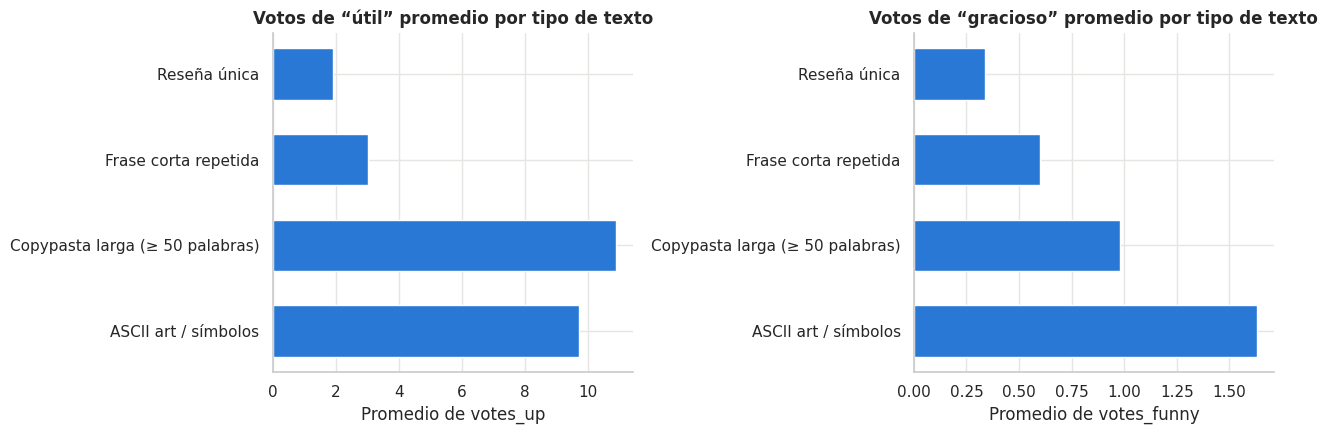

In [10]:
# Comparamos votos promedio: reseñas unicas vs cada tipo de texto repetido
unicas = df[~df.duplicated(subset='review', keep=False)]

comparacion = pd.concat([
    pd.DataFrame({'tipo': 'Reseña única', 'votes_up': unicas['votes_up'], 'votes_funny': unicas['votes_funny']}),
    repetidas[['tipo', 'votes_up', 'votes_funny']],
])

tabla_votos = comparacion.groupby('tipo').agg(
    reseñas=('votes_up', 'size'),
    votos_utiles_prom=('votes_up', 'mean'),
    votos_graciosos_prom=('votes_funny', 'mean'),
).round(2)

print(tabla_votos)


# Grafico: votos utiles y graciosos promedio por tipo
orden = ['Reseña única', 'Frase corta repetida', 'Copypasta larga (≥ 50 palabras)', 'ASCII art / símbolos']
tabla_votos = tabla_votos.reindex(orden)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(tabla_votos.index[::-1], tabla_votos['votos_utiles_prom'][::-1], color=C_MAIN, height=0.6)
axes[0].set_title('Votos de “útil” promedio por tipo de texto')
axes[0].set_xlabel('Promedio de votes_up')

axes[1].barh(tabla_votos.index[::-1], tabla_votos['votos_graciosos_prom'][::-1], color=C_MAIN, height=0.6)
axes[1].set_title('Votos de “gracioso” promedio por tipo de texto')
axes[1].set_xlabel('Promedio de votes_funny')

plt.tight_layout()
plt.show()

## 4. Preprocesamiento estructural
Cada paso de limpieza se registra en `log_limpieza` para saber cuántas filas eliminó.

In [11]:
# Lista donde guardamos (paso, filas restantes) despues de cada limpieza
log_limpieza = [('Dataset original', len(df))]


# 4.1 Eliminamos la columna vacia y las filas duplicadas exactas
df = df.drop(columns=['release_date'])
df = df.drop_duplicates()
log_limpieza.append(('Sin duplicados exactos', len(df)))


# 4.2 Eliminamos textos repetidos (nos quedamos con la primera aparicion)
df = df.drop_duplicates(subset='review', keep='first')
log_limpieza.append(('Sin textos repetidos', len(df)))

print(log_limpieza)

[('Dataset original', 730945), ('Sin duplicados exactos', 730943), ('Sin textos repetidos', 721521)]


In [12]:
# 4.3 Eliminamos reseñas sin contenido linguistico (ASCII art, solo simbolos o emojis)

# Funcion que calcula que proporcion del texto son letras
def proporcion_letras(texto):
    texto = str(texto)
    letras = sum(caracter.isalpha() for caracter in texto)
    return letras / max(len(texto), 1)


# Calculamos la proporcion para cada reseña
df['ratio_letras'] = df['review'].map(proporcion_letras)

# Nos quedamos solo con las reseñas que tienen al menos 50 % de letras
df = df[df['ratio_letras'] >= 0.5]
log_limpieza.append(('Sin ASCII art / símbolos', len(df)))

print('Filas restantes:', len(df))

Filas restantes: 718152


### 4.4 Detección de idioma
Se usa `py3langid` (modelo de identificación de idioma entrenado en 97 idiomas). Se conservan solo las
reseñas en inglés para usar un único pipeline de normalización y modelos preentrenados en inglés.

In [13]:
%%time
# Detectamos el idioma de cada reseña (tarda unos 3-4 minutos)
# langid.classify devuelve (idioma, puntaje); nos quedamos solo con el idioma
df['idioma'] = [langid.classify(str(texto))[0] for texto in df['review']]

# Cantidad de reseñas por idioma
dist_idioma = df['idioma'].value_counts()
dist_idioma.head(10)

CPU times: user 4min 3s, sys: 344 ms, total: 4min 4s
Wall time: 4min 8s


,count
idioma,
en,699881
ru,2554
pcm,2277
es,2186
pt,2028
tr,884
pl,564
de,564
id,428


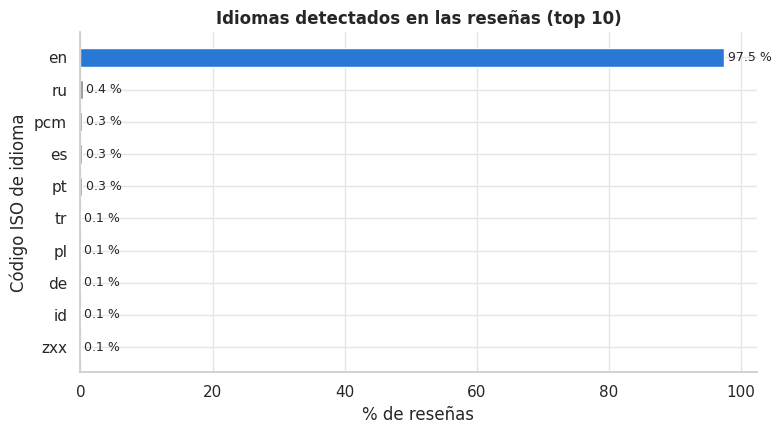

In [14]:
# Grafico de los 10 idiomas mas frecuentes (en porcentaje)

# Pasamos los conteos a porcentaje y tomamos los 10 primeros
# [::-1] invierte el orden para que el mas frecuente quede arriba en el grafico
top_idiomas = (dist_idioma / dist_idioma.sum() * 100).head(10)[::-1]

# Ingles en azul y el resto en gris
colores = [C_MAIN if idioma == 'en' else C_GRAY for idioma in top_idiomas.index]


# Grafico de barras horizontales
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_idiomas.index, top_idiomas.values, color=colores, height=0.6)

# Escribimos el porcentaje al lado de cada barra
for posicion_y, valor in enumerate(top_idiomas.values):
    ax.text(valor + 0.5, posicion_y, f'{valor:.1f} %', va='center', fontsize=9)


# Titulos y etiquetas
ax.set_title('Idiomas detectados en las reseñas (top 10)')
ax.set_xlabel('% de reseñas')
ax.set_ylabel('Código ISO de idioma')

plt.tight_layout()
plt.show()

In [15]:
# Nos quedamos solo con las reseñas en ingles
df = df[df['idioma'] == 'en'].copy()
log_limpieza.append(('Solo reseñas en inglés', len(df)))

print('Filas restantes:', len(df))

Filas restantes: 699881


### 4.5 Ingeniería de variables
- `sentimiento`: etiqueta legible de `voted_up`.
- `review_date`, `año`: fecha de publicación a partir del timestamp Unix.
- `horas_jugadas`: minutos → horas. **No se eliminan outliers de horas jugadas**: una reseña de un jugador con
  miles de horas sigue siendo un texto válido; para visualizar se usa escala logarítmica.
- `precio_usd`: centavos → dólares.
- `antiguedad_dias`: días entre la publicación y la fecha de recolección (las reseñas antiguas acumulan más votos).
- `votos_por_mes`: votos de “útil” divididos entre los meses que la reseña lleva publicada (mínimo 1). Normaliza el efecto de la antigüedad (ver 6.5).
- `helpful` (P2): 1 si la reseña recibió al menos `UMBRAL_UTIL` votos de “útil”.
- `funny` (E3): 1 si recibió al menos un voto de “gracioso”.

In [16]:
# Umbral de votos para considerar una reseña como util (se justifica en la seccion 6.5)
UMBRAL_UTIL = 2


# Etiqueta de texto para el sentimiento: True -> Positiva, False -> Negativa
df['sentimiento'] = np.where(df['voted_up'], 'Positiva', 'Negativa')


# Fechas: el timestamp Unix esta en segundos
df['review_date'] = pd.to_datetime(df['timestamp_created'], unit='s')
df['año'] = df['review_date'].dt.year


# Conversiones de unidades
df['horas_jugadas'] = df['author_playtime_forever'] / 60   # minutos -> horas
df['precio_usd'] = df['price'] / 100                       # centavos -> dolares


# Antiguedad: dias entre la publicacion y la reseña mas reciente (fecha aproximada de recoleccion)
fecha_recoleccion = df['review_date'].max()
df['antiguedad_dias'] = (fecha_recoleccion - df['review_date']).dt.days


# Votos utiles por mes de exposicion: compara reseñas antiguas y nuevas en igualdad de condiciones
# (minimo 1 mes para no dividir entre casi cero en reseñas de pocos dias)
meses_publicada = (df['antiguedad_dias'] / 30).clip(lower=1)
df['votos_por_mes'] = df['votes_up'] / meses_publicada


# Variables objetivo de P2 y E3 (1 = si, 0 = no)
df['helpful'] = (df['votes_up'] >= UMBRAL_UTIL).astype(int)
df['funny'] = (df['votes_funny'] >= 1).astype(int)


# Longitud de la reseña en caracteres
df['n_caracteres'] = df['review'].str.len()


print('Fecha de recolección aprox.:', fecha_recoleccion.date())

# Vista de las nuevas columnas
columnas_vista = ['name', 'sentimiento', 'horas_jugadas', 'precio_usd', 'votes_up', 'votos_por_mes', 'helpful', 'funny', 'review_date']
df[columnas_vista].head()

Fecha de recolección aprox.: 2025-09-15


,name,sentimiento,horas_jugadas,precio_usd,votes_up,votos_por_mes,helpful,funny,review_date
0,Call of Duty: Modern Warfare II,Positiva,24.75,69.99,0,0.00,0,0,2025-09-14 15:47:05
1,Call of Duty: Modern Warfare II,Negativa,5.77,69.99,0,0.00,0,0,2025-09-14 15:38:09
2,Call of Duty: Modern Warfare II,Negativa,35.52,69.99,0,0.00,0,0,2025-09-14 14:58:28
3,Call of Duty: Modern Warfare II,Positiva,5.73,69.99,0,0.00,0,0,2025-09-14 13:02:37
4,Call of Duty: Modern Warfare II,Negativa,29.10,69.99,0,0.00,0,1,2025-09-14 10:47:39


## 5. Normalización del texto
Pasos aplicados a cada reseña:
1. Decodificar entidades HTML y eliminar etiquetas BBCode de Steam (`[h1]`, `[b]`, `[spoiler]`…).
2. Eliminar URLs.
3. Pasar a minúsculas y expandir contracciones negativas, con o sin apóstrofo (`don't`/`dont` → `do not`, `can't` → `can not`, `won't` → `will not`).
4. Reducir letras repetidas (`sooooo` → `soo`).
5. Conservar solo letras y espacios.
6. Eliminar *stopwords*, **pero conservando las negaciones** (`not`, `no`, `never`…), porque cambian el sentimiento.
7. Lematizar con WordNet: las palabras terminadas en *-ed* se lematizan como verbo (`played` → `play`, `crashed` → `crash`)
   y el resto como sustantivo (`games` → `game`, `bugs` → `bug`). Luego se vuelve a filtrar stopwords.

**Sobre los saltos de línea (`\n`):** la columna original `review` se conserva tal cual (con `\n`), porque es el dato
fuente. En `review_norm` y `review_clean` los saltos de línea y tabulaciones se reemplazan por un espacio (paso 5).

**Sobre las stopwords:** la lista extra (`game`, `play`, `just`…) solo se aplica a `review_clean`, que usan los modelos
clásicos (TF-IDF, Naive Bayes, LDA). Los transformers (BERT/DistilBERT) usarán `review_norm`, que conserva todas las palabras.
La palabra `like` **no** se elimina porque puede tener carga de sentimiento (*“I like it”*, *“didn't like”*).

Se guardan dos versiones: `review_norm` (pasos 1–5, para transformers que necesitan el texto natural) y
`review_clean` (pasos 1–7, para modelos clásicos con TF-IDF).

In [17]:
# 5.1 Lematizador: convierte cada palabra a su forma base
import nltk
from nltk.stem import WordNetLemmatizer

# Descargamos el diccionario WordNet que usa el lematizador
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lematizador = WordNetLemmatizer()


# WordNet necesita saber si la palabra es verbo o sustantivo (POS).
# Etiquetar el POS de 700 mil reseñas tarda demasiado, asi que usamos una regla simple:
#   - palabras terminadas en "ed" -> verbo      (played -> play, crashed -> crash)
#   - el resto                    -> sustantivo (games -> game, bugs -> bug)
# Asi evitamos que adjetivos como "boring" o "amazing" se conviertan en "bore" o "amaze".
def lematizar(palabra):
    if palabra.endswith('ed'):
        return lematizador.lemmatize(palabra, pos='v')
    return lematizador.lemmatize(palabra, pos='n')


# Prueba del lematizador
for palabra in ['games', 'bugs', 'played', 'crashed', 'boring', 'amazing']:
    print(f'{palabra:>8} -> {lematizar(palabra)}')

   games -> game
    bugs -> bug
  played -> play
 crashed -> crash
  boring -> boring
 amazing -> amazing


In [18]:
# 5.2 Listas de palabras

# Negaciones: NO se eliminan porque cambian el sentido ("not good", "not worth")
NEGACIONES = {'no', 'not', 'nor', 'never', 'nothing', 'nobody', 'none', 'cannot'}

# Palabras extra que no aportan significado en este contexto
EXTRA_STOP = {
    'game', 'games', 'play', 'played', 'playing', 'just',   # aparecen en casi todas las reseñas
    'does', 'did', 'doing', 've', 'll', 're', 'im',         # restos de contracciones y verbos auxiliares
    'wa', 'ha', 'doe',                                      # por seguridad: lemas erroneos de was, has, does
}

# Nota: "like" NO se elimina porque puede expresar sentimiento ("I like it", "didn't like")
# Nota: estas stopwords solo se aplican a review_clean (modelos clasicos);
#       los transformers usaran review_norm, que conserva todas las palabras

# Stopwords finales = lista de scikit-learn + extras, quitando las negaciones
STOPWORDS = (set(ENGLISH_STOP_WORDS) | EXTRA_STOP) - NEGACIONES

print('Total de stopwords:', len(STOPWORDS))

Total de stopwords: 325


In [19]:
# 5.3 Expresiones regulares (patrones de busqueda) que usa la normalizacion

RE_BBCODE = re.compile(r'\[/?[^\]]{1,20}\]')          # etiquetas de Steam como [b], [/b], [h1], [spoiler]
RE_URL    = re.compile(r'https?://\S+|www\.\S+')      # enlaces web

# Contracciones negativas
RE_CANT   = re.compile(r"\bcan['’]?t\b")              # can't / cant   -> can not
RE_WONT   = re.compile(r"\bwon['’]t\b|\bwont\b")      # won't / wont   -> will not
RE_AINT   = re.compile(r"\bain['’]?t\b")              # ain't / aint   -> is not
RE_NT     = re.compile(r"n['’]t\b")                   # don't, isn't   -> do not, is not
RE_NT_SIN = re.compile(r"\b(do|does|did|is|was|are|were|could|would|should|have|has|had)nt\b")  # dont, isnt (sin apostrofo)

RE_REPEAT = re.compile(r'(\w)\1{2,}')                 # letras repetidas 3 o mas veces (sooooo)
RE_NOALFA = re.compile(r'[^a-z\s]')                   # todo lo que no sea letra o espacio
RE_ESP    = re.compile(r'\s+')                        # espacios multiples

In [20]:
# 5.4 Funcion normalizar: pasos 1 a 5 (texto natural, util para transformers)
def normalizar(texto):
    t = html.unescape(str(texto))     # &amp; -> &, &quot; -> "
    t = RE_BBCODE.sub(' ', t)         # quitamos etiquetas de Steam
    t = RE_URL.sub(' ', t)            # quitamos enlaces
    t = t.lower()                     # todo a minusculas

    # Expandimos contracciones negativas
    t = RE_CANT.sub('can not', t)
    t = RE_WONT.sub('will not', t)
    t = RE_AINT.sub('is not', t)
    t = RE_NT.sub(' not', t)
    t = RE_NT_SIN.sub(r'\1 not', t)

    t = RE_REPEAT.sub(r'\1\1', t)     # sooooo -> soo
    t = RE_NOALFA.sub(' ', t)         # quitamos numeros, signos y emojis
    t = RE_ESP.sub(' ', t)            # un solo espacio entre palabras (tambien elimina saltos de linea \n y tabulaciones)

    return t.strip()


# 5.5 Funcion limpiar: pasos 6 y 7 (para modelos clasicos con TF-IDF)
def limpiar(texto_norm):
    # Quitamos stopwords y palabras de una sola letra
    palabras = [p for p in texto_norm.split() if len(p) > 1 and p not in STOPWORDS]

    # Lematizamos cada palabra
    lemas = [lematizar(p) for p in palabras]

    # Volvemos a filtrar por si algun lema quedo como stopword
    lemas = [l for l in lemas if len(l) > 1 and l not in STOPWORDS]

    return ' '.join(lemas)


# Prueba con un ejemplo
ejemplo = "I DON'T recommend this [b]game[/b]... sooooo many BUGS!!! 0/10 https://store.steampowered.com"

print('Original   :', ejemplo)
print('Normalizada:', normalizar(ejemplo))
print('Limpia     :', limpiar(normalizar(ejemplo)))

Original   : I DON'T recommend this [b]game[/b]... sooooo many BUGS!!! 0/10 https://store.steampowered.com
Normalizada: i do not recommend this game soo many bugs
Limpia     : not recommend soo bug


In [21]:
%%time
# 5.6 Aplicamos la normalizacion y la limpieza a todas las reseñas (tarda unos 3-4 minutos)
df['review_norm'] = df['review'].map(normalizar)
df['review_clean'] = df['review_norm'].map(limpiar)

# Numero de palabras que quedan despues de limpiar
df['n_palabras_clean'] = df['review_clean'].str.split().str.len()


# Eliminamos reseñas que quedaron vacias o con 1 sola palabra (no aportan informacion)
df = df[df['n_palabras_clean'] >= 2].copy()
log_limpieza.append(('Con ≥ 2 palabras tras limpieza', len(df)))


# Comparamos 5 reseñas al azar: original vs limpia
df[['review', 'review_clean']].sample(5, random_state=RANDOM_STATE)

CPU times: user 2min 52s, sys: 1.79 s, total: 2min 54s
Wall time: 2min 56s


,review,review_clean
217301,'He's bouncin' on mah booty cheeks...I love the way he rides....\nI can't hardly breathe when he's pumpin' deep insi...,bouncin mah booty cheek love way ride not hardly breathe pumpin deep inside
569680,This game has the right amount of seasoning. Gordon be damned! 👌,right seasoning gordon damn
310259,Parts of the game are borderline unplayable on MnK. The running/escape sections in Chris' campaign for example. The ...,borderline unplayable mnk running escape section chris campaign example camera shift button prompt shit
88315,"Pile of SHIT game the requires a secondary login that locks you out. Don't buy this bullshit game, fuck you Ubisoft.",pile shit requires secondary login lock not buy bullshit fuck ubisoft
397367,Fun but complex game. Best played with either friends or if you're willing to participate in a community discord or ...,fun complex best friend willing participate community discord similar


In [22]:
# Verificamos que la normalizacion elimino los saltos de linea
con_salto_original = df['review'].str.contains('\n', regex=False).sum()
con_salto_norm = df['review_norm'].str.contains('\n', regex=False).sum()

print('Reseñas con \\n en review (original):', con_salto_original)
print('Reseñas con \\n en review_norm      :', con_salto_norm)

Reseñas con \n en review (original): 196162
Reseñas con \n en review_norm      : 0


In [23]:
# 5.7 Tabla resumen de la limpieza: filas que quedan y que se eliminan en cada paso
resumen = pd.DataFrame(log_limpieza, columns=['Paso', 'Filas'])

resumen['Eliminadas'] = (-resumen['Filas'].diff()).fillna(0).astype(int)
resumen['% del original'] = (resumen['Filas'] / resumen['Filas'].iloc[0] * 100).round(1)

resumen

,Paso,Filas,Eliminadas,% del original
0,Dataset original,730945,0,100.00
1,Sin duplicados exactos,730943,2,100.00
2,Sin textos repetidos,721521,9422,98.70
3,Sin ASCII art / símbolos,718152,3369,98.20
4,Solo reseñas en inglés,699881,18271,95.80
5,Con ≥ 2 palabras tras limpieza,693605,6276,94.90


## 6. Análisis exploratorio y visualización

### 6.1 Balance de clases (P1)

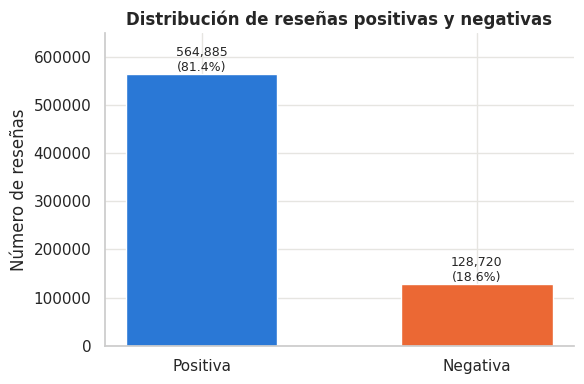

In [24]:
# Cantidad de reseñas positivas y negativas
conteo = df['sentimiento'].value_counts().reindex(['Positiva', 'Negativa'])


# Grafico de barras
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conteo.index, conteo.values, color=[C_POS, C_NEG], width=0.55)

# Escribimos la cantidad y el porcentaje encima de cada barra
total = conteo.sum()
for posicion_x, valor in enumerate(conteo.values):
    ax.text(posicion_x, valor, f'{valor:,}\n({valor / total:.1%})', ha='center', va='bottom', fontsize=9)


# Titulos y etiquetas
ax.set_title('Distribución de reseñas positivas y negativas')
ax.set_ylabel('Número de reseñas')
ax.margins(y=0.15)   # espacio arriba para que entren los textos

plt.tight_layout()
plt.show()

El dataset está **desbalanceado** (≈ 4 positivas por cada negativa). Por eso, además de *accuracy*, se usarán
F1 macro, precisión/recall por clase y AUC-ROC, y se probará `class_weight='balanced'` o submuestreo.

### 6.2 Reseñas y tasa de recomendación por juego

In [25]:
# Resumen por juego: numero de reseñas, % de positivas y precio
por_juego = df.groupby('name').agg(
    n_reseñas=('voted_up', 'size'),
    tasa_positiva=('voted_up', 'mean'),
    precio_usd=('precio_usd', 'first'),
).reset_index()

# Estadisticas del numero de reseñas por juego
por_juego['n_reseñas'].describe().round(1)

,n_reseñas
count,735.00
mean,943.70
std,129.40
min,1.00
25%,942.00
50%,956.00
75%,967.00
max,1883.00


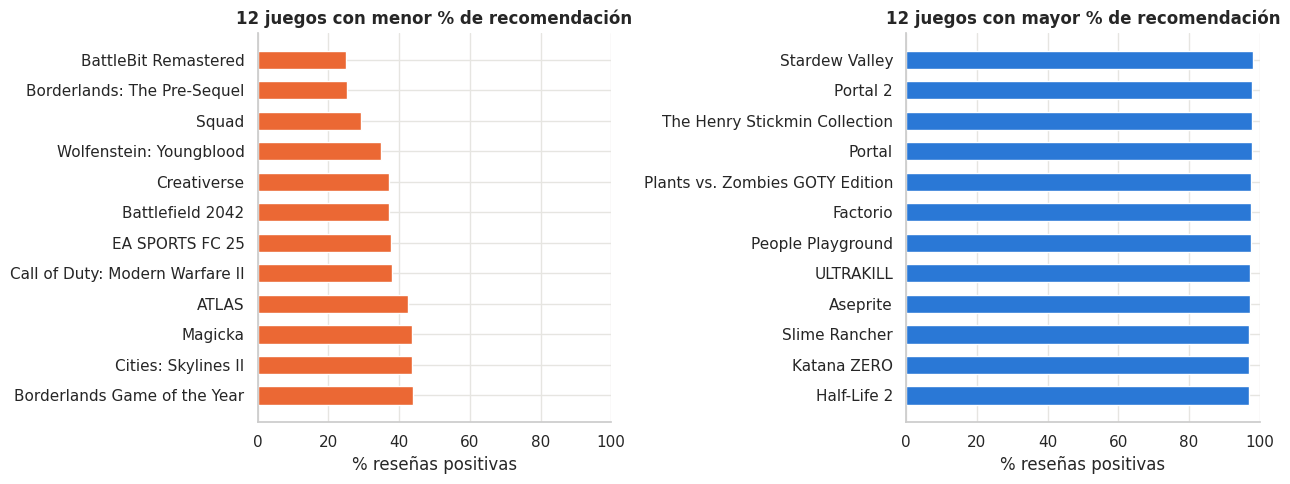

In [26]:
# Juegos con menor y mayor % de recomendacion

# Solo consideramos juegos con suficientes reseñas para que el porcentaje sea confiable
MIN_N = int(min(200, por_juego['n_reseñas'].quantile(0.25)))
juegos_validos = por_juego[por_juego['n_reseñas'] >= MIN_N]

# Los 12 peores y los 12 mejores ([::-1] para que el extremo quede arriba)
top_neg = juegos_validos.nsmallest(12, 'tasa_positiva')[::-1]
top_pos = juegos_validos.nlargest(12, 'tasa_positiva')[::-1]


# Dos graficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: menor recomendacion
axes[0].barh(top_neg['name'].str[:35], top_neg['tasa_positiva'] * 100, color=C_NEG, height=0.6)
axes[0].set_title('12 juegos con menor % de recomendación')
axes[0].set_xlabel('% reseñas positivas')
axes[0].set_xlim(0, 100)

# Derecha: mayor recomendacion
axes[1].barh(top_pos['name'].str[:35], top_pos['tasa_positiva'] * 100, color=C_POS, height=0.6)
axes[1].set_title('12 juegos con mayor % de recomendación')
axes[1].set_xlabel('% reseñas positivas')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

### 6.3 Longitud de la reseña según sentimiento

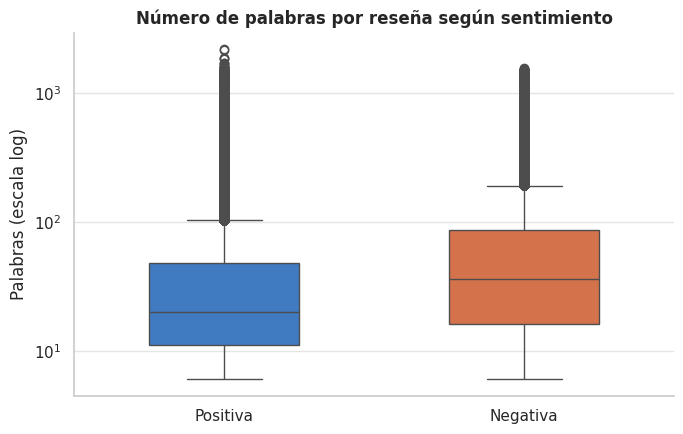

,count,mean,std,min,25%,50%,75%,max
sentimiento,,,,,,,,
Negativa,128720.00,81.00,135.00,6.00,16.00,36.00,86.00,1560.00
Positiva,564885.00,53.10,105.40,6.00,11.00,20.00,48.00,2189.00


In [27]:
# Boxplot del numero de palabras por sentimiento
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=df,
    x='sentimiento',
    y='word_count',
    order=['Positiva', 'Negativa'],
    palette=PAL_SENT,
    width=0.5,
    ax=ax,
)

# Escala logaritmica porque hay reseñas muy largas
ax.set_yscale('log')

# Titulos y etiquetas
ax.set_title('Número de palabras por reseña según sentimiento')
ax.set_xlabel('')
ax.set_ylabel('Palabras (escala log)')

plt.tight_layout()
plt.show()


# Estadisticas de la longitud por sentimiento
df.groupby('sentimiento')['word_count'].describe().round(1)

### 6.4 Horas jugadas según sentimiento

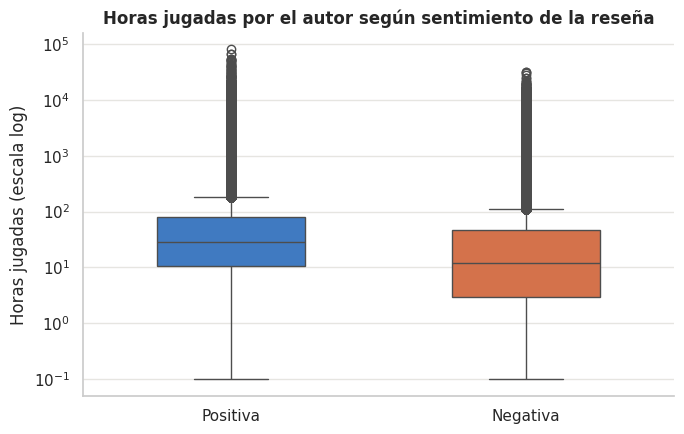

,horas_jugadas
sentimiento,
Negativa,12.00
Positiva,28.20


In [28]:
# Boxplot de horas jugadas por sentimiento

# Reemplazamos 0 horas por 0.1 porque la escala logaritmica no admite ceros
datos_horas = df.assign(horas=df['horas_jugadas'].clip(lower=0.1))

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=datos_horas,
    x='sentimiento',
    y='horas',
    order=['Positiva', 'Negativa'],
    palette=PAL_SENT,
    width=0.5,
    ax=ax,
)

ax.set_yscale('log')

# Titulos y etiquetas
ax.set_title('Horas jugadas por el autor según sentimiento de la reseña')
ax.set_xlabel('')
ax.set_ylabel('Horas jugadas (escala log)')

plt.tight_layout()
plt.show()


# Mediana de horas jugadas por sentimiento
df.groupby('sentimiento')['horas_jugadas'].median().round(1)

### 6.5 Votos de “útil” (P2) y de “gracioso” (E3)
La distribución de `votes_up` define el umbral de la variable `helpful`.

In [29]:
# Percentiles de votos utiles para justificar el umbral
print('Percentiles de votes_up:')
print(df['votes_up'].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).to_string())

# Porcentaje de reseñas utiles y graciosas
print(f"\nhelpful = votes_up ≥ {UMBRAL_UTIL}: {df['helpful'].mean():.1%} de reseñas útiles")
print(f"funny   = votes_funny ≥ 1: {df['funny'].mean():.1%} de reseñas graciosas")

Percentiles de votes_up:
0.50    0.00
0.75    1.00
0.90    3.00
0.95    7.00
0.99   31.00

helpful = votes_up ≥ 2: 18.4% de reseñas útiles
funny   = votes_funny ≥ 1: 11.9% de reseñas graciosas


Q1 = 0 | Q3 = 1 | IQR = 1 | bigote superior = 2.5 votos
Reseñas atípicas (más de 2.5 votos): 12.7%


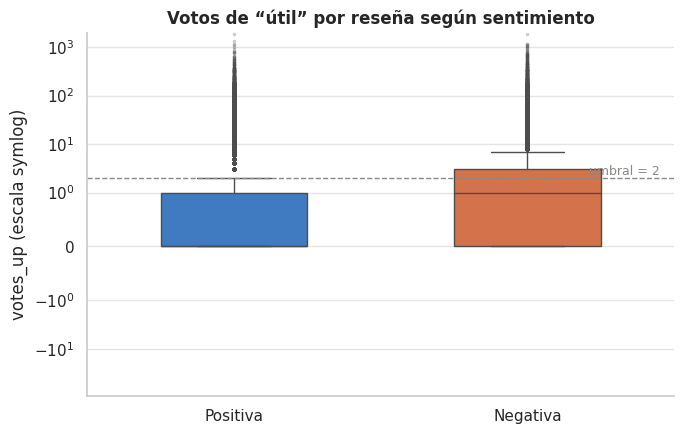

In [30]:
# Boxplot de votos utiles por sentimiento: muestra que pocas reseñas concentran muchos votos

# Cuartiles y bigote superior (Q3 + 1.5 * IQR): lo que pasa del bigote es atipico
q1 = df['votes_up'].quantile(0.25)
q3 = df['votes_up'].quantile(0.75)
iqr = q3 - q1
bigote_superior = q3 + 1.5 * iqr

print(f'Q1 = {q1:.0f} | Q3 = {q3:.0f} | IQR = {iqr:.0f} | bigote superior = {bigote_superior:.1f} votos')
print(f'Reseñas atípicas (más de {bigote_superior:.1f} votos): {(df["votes_up"] > bigote_superior).mean():.1%}')


fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=df,
    x='sentimiento',
    y='votes_up',
    order=['Positiva', 'Negativa'],
    palette=PAL_SENT,
    width=0.5,
    flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.3},   # puntos atipicos pequeños
    ax=ax,
)

# Escala symlog: lineal cerca de 0 y logaritmica para valores grandes (admite ceros)
ax.set_yscale('symlog', linthresh=1)
ax.set_ylim(bottom=0)   # los votos no pueden ser negativos: quitamos la zona vacia bajo el 0

# Linea del umbral elegido para "helpful"
ax.axhline(UMBRAL_UTIL, color=C_GRAY, ls='--', lw=1)
ax.text(1.45, UMBRAL_UTIL, f'umbral = {UMBRAL_UTIL}', va='bottom', ha='right', fontsize=9, color=C_GRAY)


# Titulos y etiquetas
ax.set_title('Votos de “útil” por reseña según sentimiento')
ax.set_xlabel('')
ax.set_ylabel('votes_up (escala symlog)')

plt.tight_layout()
plt.show()

La caja queda aplastada entre 0 y 1 voto: la reseña típica casi no recibe votos y todo lo que supera el
bigote superior (Q3 + 1.5·IQR) es atípico. El umbral `helpful = votes_up ≥ 2` separa a las reseñas que recibieron una
validación clara de la comunidad del grueso que no recibe ninguna.

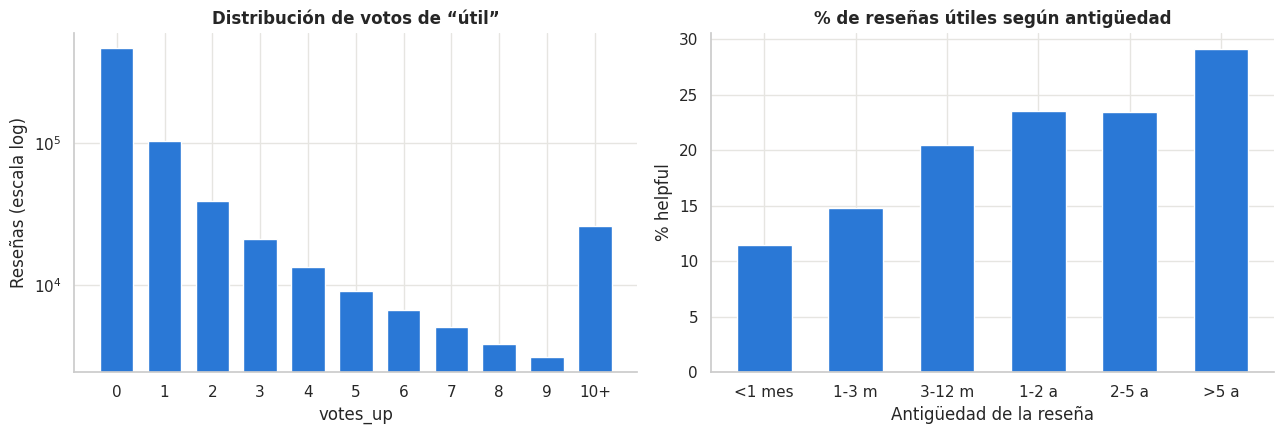

In [31]:
# Agrupamos la antiguedad en rangos para ver si las reseñas antiguas tienen mas votos
df['antig_bin'] = pd.cut(
    df['antiguedad_dias'],
    bins=[-1, 30, 90, 365, 730, 1825, 1e6],
    labels=['<1 mes', '1-3 m', '3-12 m', '1-2 a', '2-5 a', '>5 a'],
)

# % de reseñas utiles en cada rango de antiguedad
tasa_util = df.groupby('antig_bin', observed=True)['helpful'].mean() * 100

# Conteo de votos utiles (todo lo que sea 10 o mas se agrupa en "10+")
votos = df['votes_up'].clip(upper=10).value_counts().sort_index()
etiquetas_votos = [str(v) if v < 10 else '10+' for v in votos.index]


# Dos graficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: distribucion de votos utiles
axes[0].bar(etiquetas_votos, votos.values, color=C_MAIN, width=0.7)
axes[0].set_yscale('log')
axes[0].set_title('Distribución de votos de “útil”')
axes[0].set_xlabel('votes_up')
axes[0].set_ylabel('Reseñas (escala log)')

# Derecha: % de reseñas utiles segun antiguedad
axes[1].bar(tasa_util.index.astype(str), tasa_util.values, color=C_MAIN, width=0.6)
axes[1].set_title('% de reseñas útiles según antigüedad')
axes[1].set_xlabel('Antigüedad de la reseña')
axes[1].set_ylabel('% helpful')

plt.tight_layout()
plt.show()

**¿Por qué las reseñas más antiguas tienen más votos de “útil”?** Los votos son **acumulativos** y nunca se
pierden: una reseña de hace 5 años estuvo 5 años expuesta a votos, mientras que una de la semana pasada tuvo solo unos días.
Además, Steam muestra primero las reseñas “más útiles”, lo que les da todavía más visibilidad (efecto *bola de nieve*).
Es cierto que una reseña antigua puede perder **vigencia** (el juego recibió parches), pero su contador de votos no baja.

Por eso, el número total de votos no compara en igualdad de condiciones. Una métrica más justa sería
*votos por cada mil visitas*, pero Steam no publica las visitas de cada reseña. La alternativa disponible es
**`votos_por_mes`** (votos ÷ meses publicada), que se analiza a continuación. Para P2 se incluirá `antiguedad_dias`
como variable de control y se evaluará `votos_por_mes` como definición alternativa del objetivo.

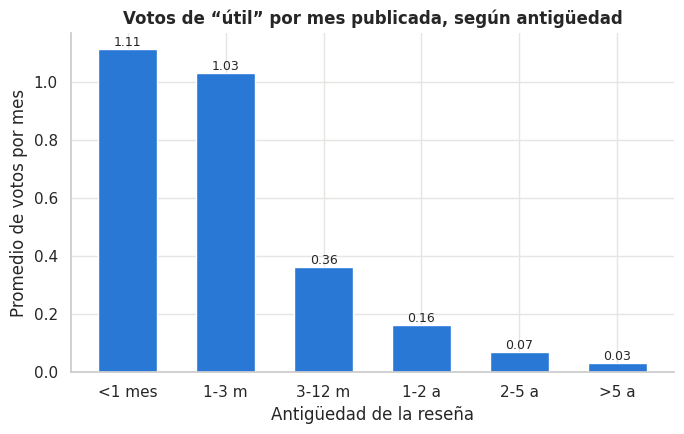

In [32]:
# Comparamos el % de reseñas utiles (votos acumulados) con los votos por mes (normalizado)
votos_mes_por_antig = df.groupby('antig_bin', observed=True)['votos_por_mes'].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(votos_mes_por_antig.index.astype(str), votos_mes_por_antig.values, color=C_MAIN, width=0.6)

# Escribimos el valor encima de cada barra
for posicion_x, valor in enumerate(votos_mes_por_antig.values):
    ax.text(posicion_x, valor, f'{valor:.2f}', ha='center', va='bottom', fontsize=9)


# Titulos y etiquetas
ax.set_title('Votos de “útil” por mes publicada, según antigüedad')
ax.set_xlabel('Antigüedad de la reseña')
ax.set_ylabel('Promedio de votos por mes')

plt.tight_layout()
plt.show()

### 6.6 Evolución temporal

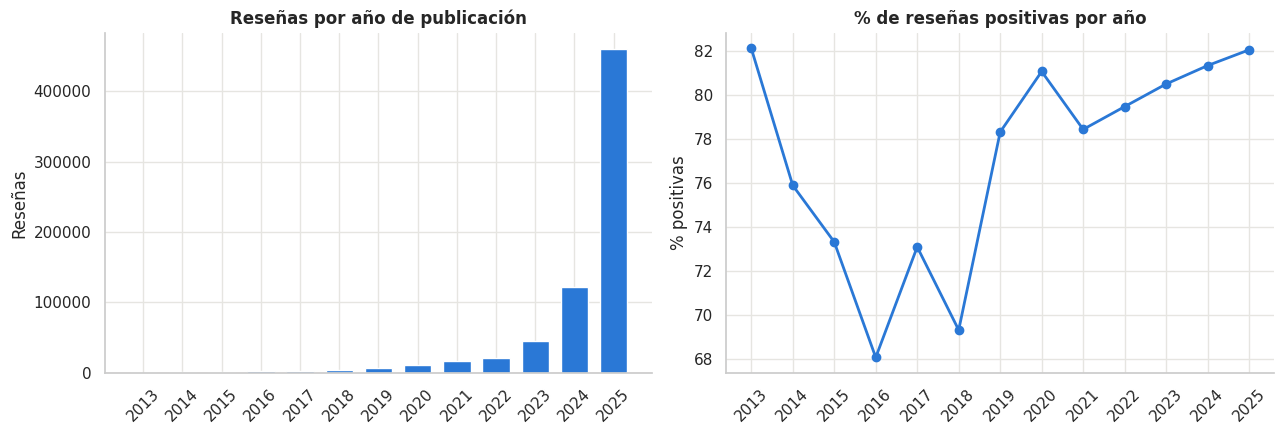

In [33]:
# Numero de reseñas y % de positivas por año
por_año = df.groupby('año').agg(
    n=('voted_up', 'size'),
    tasa=('voted_up', 'mean'),
)

# Quitamos los años con menos de 100 reseñas (porcentajes poco confiables)
por_año = por_año[por_año['n'] >= 100]
años = por_año.index.astype(str)


# Dos graficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: reseñas por año
axes[0].bar(años, por_año['n'], color=C_MAIN, width=0.7)
axes[0].set_title('Reseñas por año de publicación')
axes[0].set_ylabel('Reseñas')
axes[0].tick_params(axis='x', rotation=45)

# Derecha: % de positivas por año
axes[1].plot(años, por_año['tasa'] * 100, color=C_MAIN, lw=2, marker='o', ms=6)
axes[1].set_title('% de reseñas positivas por año')
axes[1].set_ylabel('% positivas')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6.7 Precio del juego y recomendación

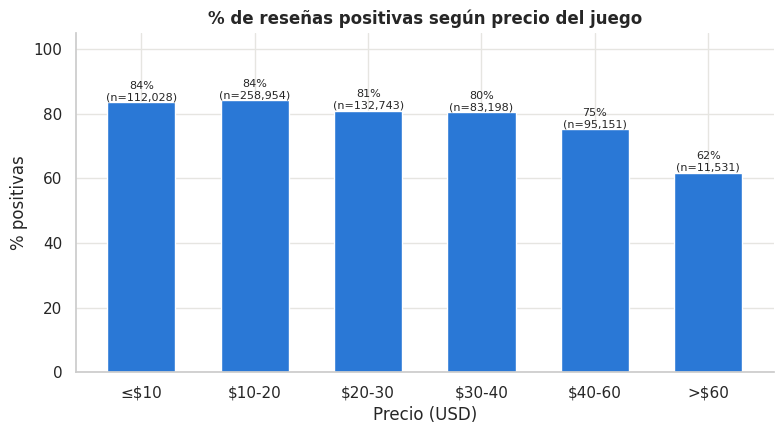

In [34]:
# Agrupamos los precios en rangos
df['rango_precio'] = pd.cut(
    df['precio_usd'],
    bins=[0, 10, 20, 30, 40, 60, 100],
    labels=['≤$10', '$10-20', '$20-30', '$30-40', '$40-60', '>$60'],
)

# % de positivas (mean) y numero de reseñas (size) por rango de precio
por_precio = df.groupby('rango_precio', observed=True)['voted_up'].agg(['mean', 'size'])


# Grafico de barras
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(por_precio.index.astype(str), por_precio['mean'] * 100, color=C_MAIN, width=0.6)

# Escribimos el % y la cantidad de reseñas encima de cada barra
for posicion_x, (tasa, n) in enumerate(por_precio.values):
    ax.text(posicion_x, tasa * 100 + 0.5, f'{tasa:.0%}\n(n={int(n):,})', ha='center', fontsize=8)


# Titulos y etiquetas
ax.set_ylim(0, 105)
ax.set_title('% de reseñas positivas según precio del juego')
ax.set_xlabel('Precio (USD)')
ax.set_ylabel('% positivas')

plt.tight_layout()
plt.show()

### 6.8 Palabras y bigramas más frecuentes por sentimiento

In [35]:
# Funcion que devuelve las k palabras (o bigramas) mas frecuentes de un conjunto de textos
def top_ngramas(textos, ngram=(1, 1), k=15):
    # En palabras sueltas omitimos las negaciones: "not" domina ambas clases y tapa el resto
    if ngram == (1, 1):
        excluir = list(NEGACIONES)
    else:
        excluir = None

    # Contamos cuantas veces aparece cada palabra o bigrama
    contador = CountVectorizer(ngram_range=ngram, min_df=5, max_features=20000, stop_words=excluir)
    matriz = contador.fit_transform(textos)
    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()

    # Ordenamos de mayor a menor y tomamos las k primeras
    indices = frecuencias.argsort()[::-1][:k]
    terminos = np.array(contador.get_feature_names_out())[indices]

    return pd.Series(frecuencias[indices], index=terminos)


# Usamos una muestra de 150 mil reseñas para que sea mas rapido
muestra = df.sample(min(len(df), 150_000), random_state=RANDOM_STATE)

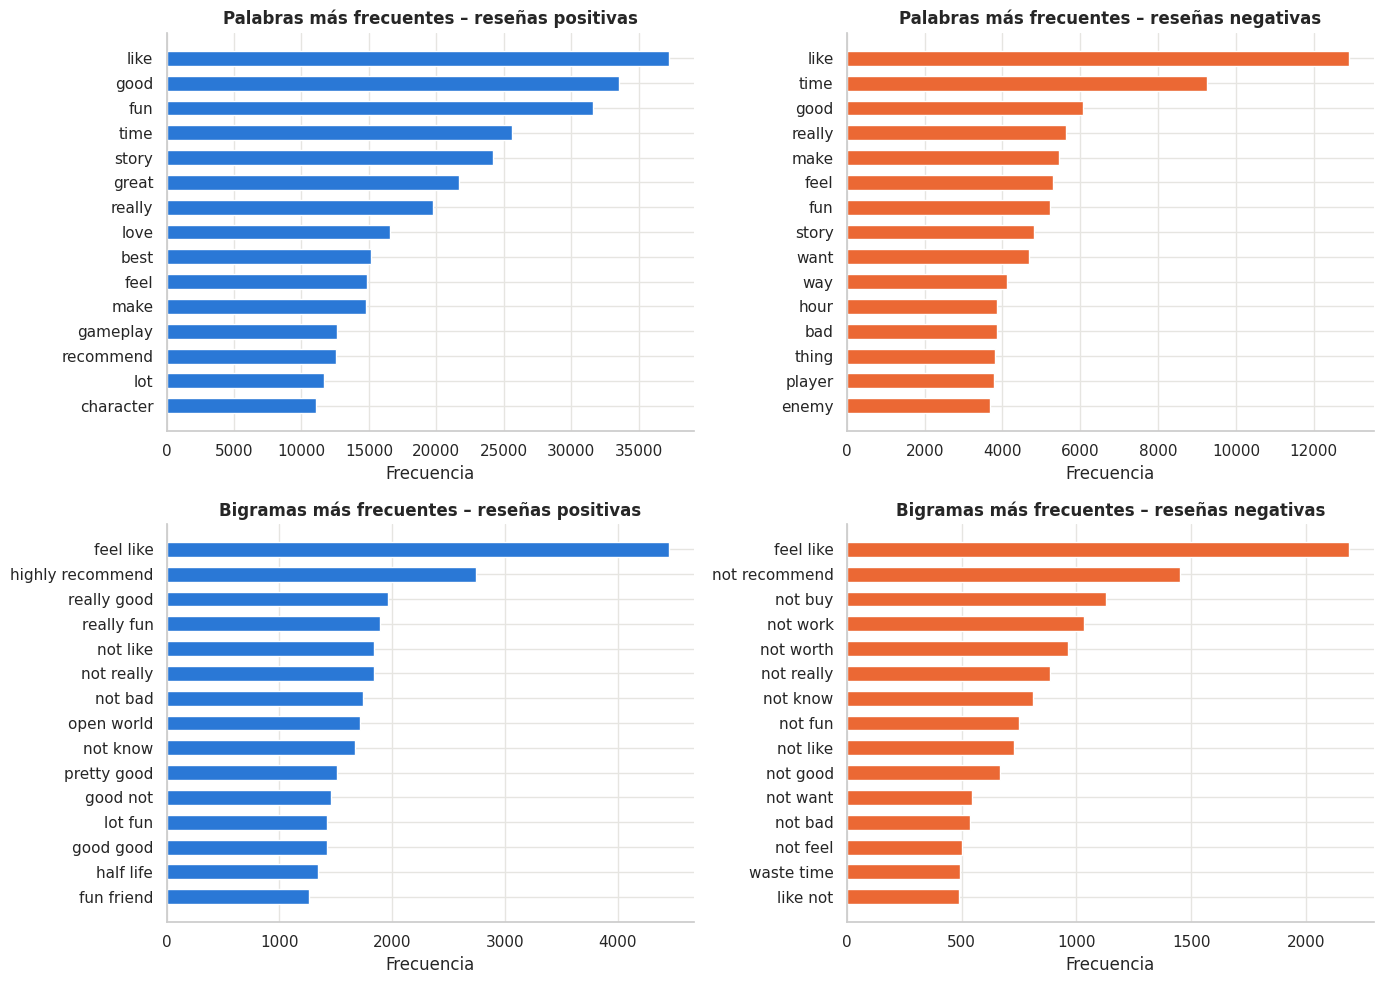

In [36]:
# Cuadricula de 2x2: filas = palabras / bigramas, columnas = positivas / negativas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for columna, (sentimiento, color) in enumerate(PAL_SENT.items()):
    textos = muestra.loc[muestra['sentimiento'] == sentimiento, 'review_clean']

    for fila, ngram in enumerate([(1, 1), (2, 2)]):
        frecuentes = top_ngramas(textos, ngram)[::-1]
        tipo = 'Palabras' if ngram == (1, 1) else 'Bigramas'

        ax = axes[fila, columna]
        ax.barh(frecuentes.index, frecuentes.values, color=color, height=0.6)
        ax.set_title(f'{tipo} más frecuentes – reseñas {sentimiento.lower()}s')
        ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

### 6.9 Nubes de palabras

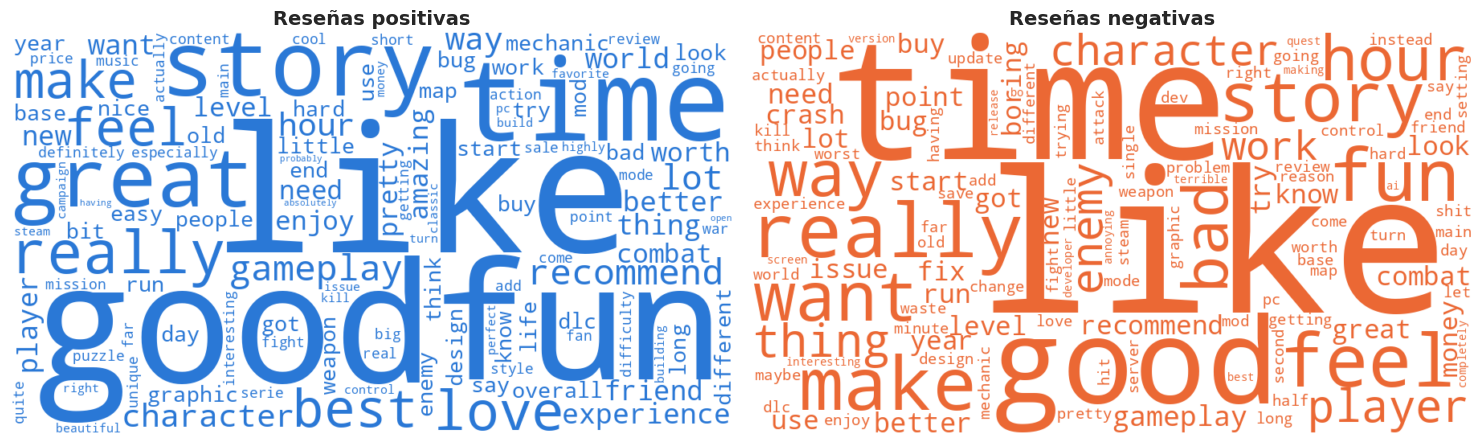

In [37]:
# Una nube de palabras para cada sentimiento
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (sentimiento, color) in zip(axes, PAL_SENT.items()):
    # Unimos todas las reseñas de ese sentimiento en un solo texto
    texto = ' '.join(muestra.loc[muestra['sentimiento'] == sentimiento, 'review_clean'])

    # Generamos la nube (sin negaciones y con un solo color por sentimiento)
    nube = WordCloud(
        width=900,
        height=500,
        background_color='white',
        max_words=120,
        stopwords=NEGACIONES,
        collocations=False,
        color_func=lambda *args, c=color, **kwargs: c,
    ).generate(texto)

    ax.imshow(nube, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Reseñas {sentimiento.lower()}s', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.10 Exploración para la pregunta extra E2: reseñas incoherentes

**¿Qué es VADER?** *Valence Aware Dictionary and sEntiment Reasoner* (Hutto y Gilbert, 2014) es un analizador de sentimiento
basado en un **diccionario de palabras con puntaje** (por ejemplo, *great* = positivo, *terrible* = negativo) más reglas que
ajustan ese puntaje según mayúsculas (*GREAT*), signos de exclamación, intensificadores (*very*), negaciones (*not good*),
emojis y jerga. Devuelve un puntaje `compound` entre −1 (muy negativo) y +1 (muy positivo).
**¿Por qué se usa aquí?** Porque fue diseñado para texto informal de redes sociales, como las reseñas de Steam, y no necesita
entrenamiento: sirve como una “segunda opinión” independiente para contrastar con lo que el usuario marcó (`voted_up`).

Se calcula el sentimiento léxico del texto con VADER y se compara con la recomendación del usuario.
Una reseña con texto muy negativo (compound < −0.5) que **sí** recomienda el juego, o una muy positiva
(compound > 0.5) que **no** lo recomienda, es candidata a ironía, sarcasmo o error del usuario.

In [38]:
%%time
# Analizador de sentimiento VADER
vader = SentimentIntensityAnalyzer()

# Muestra de 50 mil reseñas (VADER es lento para todo el dataset)
m2 = df.sample(min(len(df), 50_000), random_state=RANDOM_STATE).copy()

# Puntaje compound: de -1 (muy negativo) a +1 (muy positivo)
m2['vader'] = m2['review_norm'].map(lambda texto: vader.polarity_scores(texto)['compound'])


# Incoherente = texto muy negativo pero recomienda, o texto muy positivo pero no recomienda
negativa_pero_recomienda = (m2['vader'] < -0.5) & (m2['voted_up'])
positiva_pero_no_recomienda = (m2['vader'] > 0.5) & (~m2['voted_up'])
m2['incoherente'] = negativa_pero_recomienda | positiva_pero_no_recomienda

print(f"Reseñas potencialmente incoherentes: {m2['incoherente'].mean():.1%}")

Reseñas potencialmente incoherentes: 10.1%
CPU times: user 44.2 s, sys: 21.9 ms, total: 44.2 s
Wall time: 44.6 s


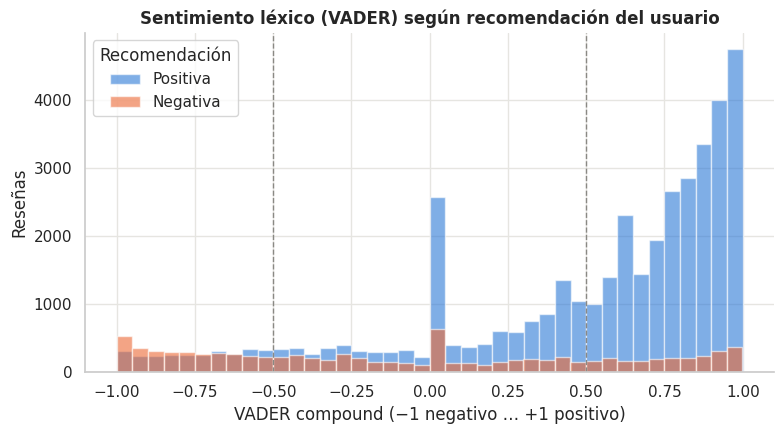

In [39]:
# Histograma del puntaje VADER separado por recomendacion
fig, ax = plt.subplots(figsize=(8, 4.5))

for sentimiento, color in PAL_SENT.items():
    puntajes = m2.loc[m2['sentimiento'] == sentimiento, 'vader']
    ax.hist(puntajes, bins=40, alpha=0.6, color=color, label=sentimiento)

# Lineas punteadas en los umbrales -0.5 y +0.5
ax.axvline(-0.5, color=C_GRAY, ls='--', lw=1)
ax.axvline(0.5, color=C_GRAY, ls='--', lw=1)


# Titulos y etiquetas
ax.set_title('Sentimiento léxico (VADER) según recomendación del usuario')
ax.set_xlabel('VADER compound (−1 negativo … +1 positivo)')
ax.set_ylabel('Reseñas')
ax.legend(title='Recomendación')

plt.tight_layout()
plt.show()

In [40]:
# Ejemplos de reseñas incoherentes
m2.loc[m2['incoherente'], ['name', 'sentimiento', 'vader', 'review']].head(8)

,name,sentimiento,vader,review
74876,Dragon's Dogma 2,Negativa,0.90,You have to be a very certain person to like these games. i am not one of them immediate buyer remorse.\nIf you are ...
272794,Manor Lords,Negativa,0.83,The biggest problem with the game right now is that each plot area is almost independent of the others. The game's g...
451680,Thief,Positiva,-0.57,"Chill, in dark mode stealing others' gold xdd"
80902,"Warhammer 40,000: Chaos Gate - Daemonhunters",Positiva,-0.68,"If you like games turn based rpgs like xcom, pheonix point, othercide etc. You are in for a treat. The story is all ..."
557404,Persona 4 Golden,Positiva,-0.56,this game is a pile of shit
400261,"Warhammer 40,000: Space Marine - Anniversary Edition",Positiva,-0.78,"A great 3rd person shooter, from the golden age of gaming. You truly feel like an unstoppable killing machine... Wel..."
660946,Liar's Bar,Positiva,-0.64,I'm not a liar you're a liar!!! shit... you called my bluff... 10/10 will lie again
284554,Outlast,Positiva,-0.68,Same as Alien Isolation finding the right path was as painful 10/10


### 6.11 Hallazgos principales del EDA
- **Desbalance:** ≈ 81 % de reseñas positivas frente a ≈ 19 % negativas.
- **Longitud:** las reseñas negativas son más largas que las positivas.
- **Horas jugadas:** quienes recomiendan el juego jugaron más horas.
- **Utilidad:** solo una minoría de reseñas recibe ≥ 2 votos de “útil”, y las más antiguas acumulan más votos.
- **Precio:** a mayor precio, menor porcentaje de reseñas positivas.
- **Vocabulario:** términos como *fun, great, story, highly recommend* frente a *not recommend, not worth, waste time*.
- **Votos y antigüedad:** el total de votos favorece a las reseñas antiguas; `votos_por_mes` permite compararlas en igualdad de condiciones.
- **Textos repetidos:** existen copypastas largas publicadas en muchos juegos y *ASCII art*, que se eliminaron para no sesgar los modelos.
- **Incoherencia:** alrededor del 10 % de reseñas tiene un texto que contradice su recomendación según VADER.

## 7. Propuesta de modelización

| Pregunta | Representación del texto | Algoritmos propuestos | Métricas |
|---|---|---|---|
| **P1** Recomienda o no | TF-IDF (uni+bigramas) · embeddings `all-MiniLM-L6-v2` · texto crudo para transformer | Regresión Logística, Naive Bayes Multinomial, Linear SVM (baseline) · DistilBERT afinado | Accuracy, F1 macro, precisión/recall por clase, AUC-ROC, matriz de confusión |
| **P2** Será útil | TF-IDF + variables numéricas (`word_count`, `horas_jugadas`, `antiguedad_dias`) | Regresión Logística, Random Forest, LightGBM · DistilBERT | F1 de la clase positiva, AUC-ROC, AUC-PR (clase minoritaria) |
| **P3** Tema | Embeddings de oraciones | BERTopic (o LDA como baseline) para descubrir tópicos → etiquetado → clasificador multiclase (Regresión Logística / SVM) | Coherencia de tópicos (c_v), F1 macro del clasificador |
| **E1** Recomendador | Perfil de cada juego = promedio de embeddings de sus reseñas | Similitud coseno *content-based*; explicación con términos TF-IDF compartidos (XAI) | Precision@k y evaluación cualitativa |
| **E2** Incoherencia | VADER / modelo P1 vs. `voted_up` | Reglas de discrepancia + revisión manual de una muestra | % de acierto sobre muestra etiquetada a mano |
| **E3** Graciosa | TF-IDF + embeddings | Regresión Logística, Linear SVM | F1, AUC-PR |

**Protocolo experimental:** partición estratificada 80/20 (train/test) con validación cruzada de 5 folds en train,
`class_weight='balanced'` para las clases minoritarias, y explicación de predicciones con coeficientes del modelo
lineal y SHAP/LIME (Explainable AI). Resultados en tablas comparativas por pregunta.

**Interfaz para stakeholders (TF):** aplicación en Streamlit donde se pega una reseña y se muestra si es
positiva, si probablemente será útil, su tema y juegos recomendados.

### 7.1 Experimento preliminar para P1 (baseline)
Un primer modelo TF-IDF + Regresión Logística comprueba que el texto preparado tiene señal suficiente.

In [41]:
# Librerias del modelo
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


# Muestra de 200 mil reseñas para entrenar mas rapido
base = df.sample(min(len(df), 200_000), random_state=RANDOM_STATE)

X = base['review_clean']               # texto limpio (entrada)
y = base['voted_up'].astype(int)       # 1 = recomienda, 0 = no recomienda


# Separamos 80 % entrenamiento y 20 % prueba, manteniendo la proporcion de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Entrenamiento:', len(X_train), '| Prueba:', len(X_test))

Entrenamiento: 160000 | Prueba: 40000


In [42]:
# Convertimos el texto en numeros con TF-IDF (palabras sueltas y bigramas)
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),      # palabras y pares de palabras
    min_df=3,                # ignora terminos que aparecen en menos de 3 reseñas
    max_features=100_000,    # maximo de terminos
    sublinear_tf=True,       # suaviza el peso de palabras muy repetidas
)

X_train_vec = tfidf.fit_transform(X_train)   # aprende el vocabulario con entrenamiento
X_test_vec = tfidf.transform(X_test)         # aplica el mismo vocabulario a prueba


# Entrenamos la Regresion Logistica (class_weight='balanced' compensa el desbalance de clases)
modelo = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [43]:
# Evaluamos el modelo con el conjunto de prueba
pred = modelo.predict(X_test_vec)                  # clase predicha (0 o 1)
proba = modelo.predict_proba(X_test_vec)[:, 1]     # probabilidad de ser positiva

print(classification_report(y_test, pred, target_names=['Negativa', 'Positiva'], digits=3))
print('AUC-ROC:', round(roc_auc_score(y_test, proba), 4))

              precision    recall  f1-score   support

    Negativa      0.641     0.837     0.726      7420
    Positiva      0.960     0.893     0.926     32580

    accuracy                          0.883     40000
   macro avg      0.801     0.865     0.826     40000
weighted avg      0.901     0.883     0.889     40000

AUC-ROC: 0.9408


In [44]:
# Terminos con mas peso hacia cada clase (interpretabilidad del modelo)
coeficientes = pd.Series(modelo.coef_[0], index=tfidf.get_feature_names_out())

pd.DataFrame({
    'Más negativas': coeficientes.nsmallest(15).index,
    'Más positivas': coeficientes.nlargest(15).index,
})

,Más negativas,Más positivas
0,not worth,best
1,boring,great
2,not recommend,love
3,unplayable,good
4,not,fun
5,not fun,amazing
6,worst,awesome
7,awful,not bad
8,poorly,excellent
9,crash,fantastic


## 8. Exportación del dataset preparado
- `data/steam_reviews_clean.csv`: dataset final completo.
- `data/steam_reviews_clean_sample.csv`: muestra estratificada de 50 000 reseñas para el repositorio de GitHub
  (GitHub no admite archivos de más de 100 MB; el original pesa ~285 MB, así que en el README se enlaza a Kaggle).

In [45]:
# Creamos la carpeta data si no existe
os.makedirs('data', exist_ok=True)


# Columnas que guardamos en el dataset final
columnas_finales = [
    'appid', 'name', 'review', 'review_norm', 'review_clean',
    'voted_up', 'sentimiento', 'word_count', 'n_palabras_clean',
    'votes_up', 'votes_funny', 'helpful', 'funny',
    'horas_jugadas', 'precio_usd', 'review_date', 'año', 'antiguedad_dias', 'votos_por_mes',
]
df_final = df[columnas_finales]


# Guardamos el dataset completo
df_final.to_csv('data/steam_reviews_clean.csv', index=False)

In [46]:
# Muestra de 50 mil reseñas manteniendo la proporcion de positivas y negativas (para GitHub)
n_muestra = min(50_000, len(df_final))
fraccion = n_muestra / len(df_final)

muestra_github = df_final.groupby('voted_up', group_keys=False).apply(
    lambda grupo: grupo.sample(frac=fraccion, random_state=RANDOM_STATE)
)
muestra_github.to_csv('data/steam_reviews_clean_sample.csv', index=False)


# Tamano de los archivos generados
print('Dataset final:', df_final.shape)

for archivo in ['data/steam_reviews_clean.csv', 'data/steam_reviews_clean_sample.csv']:
    tamano_mb = os.path.getsize(archivo) / 1e6
    print(f'{archivo}: {tamano_mb:.1f} MB')

Dataset final: (693605, 19)
data/steam_reviews_clean.csv: 635.8 MB
data/steam_reviews_clean_sample.csv: 46.2 MB
